# Initial Data cleaning

In [251]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [252]:
# Get initial ball data
ball_data = pd.read_csv('data/ball-data.csv')

# Get initial match data
match_data = pd.read_csv('data/match-info.csv')
match_data = match_data.rename(columns={'match_number': 'ID'})
match_data.head()

# Get merged data
merged_data = pd.merge(ball_data, match_data, on='ID', how='left')
merged_data.head()

,ID,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,ExtraType,BatsmanRun,ExtrasRun,...,toss_winner,toss_decision,result,eliminator,winner,player_of_match,venue,city,team1_players,team2_players
0,501208,1,0,1,S Sohal,Z Khan,S Dhawan,NaN,0,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
1,501208,1,0,2,S Sohal,Z Khan,S Dhawan,NaN,1,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
2,501208,1,0,3,S Dhawan,Z Khan,S Sohal,NaN,1,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
3,501208,1,0,4,S Sohal,Z Khan,S Dhawan,NaN,0,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
4,501208,1,0,5,S Sohal,Z Khan,S Dhawan,wides,0,1,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."


In [253]:
merged_data.columns

Index(['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler',
       'NonStriker', 'ExtraType', 'BatsmanRun', 'ExtrasRun', 'TotalRun',
       'IsWicketDelivery', 'PlayerOut', 'Kind', 'FieldersInvolved',
       'BattingTeam', 'team1', 'team2', 'match_date', 'toss_winner',
       'toss_decision', 'result', 'eliminator', 'winner', 'player_of_match',
       'venue', 'city', 'team1_players', 'team2_players'],
      dtype='str')

In [254]:
filtered_df = merged_data.drop(columns=['Batter', 'NonStriker', 'toss_winner', 'toss_decision', 'result', 'eliminator', 'venue', 'city', 'team1', 'team2', 'city', 'team1_players', 'team2_players', 'player_of_match', 'winner', 'BattingTeam'])
filtered_df.sort_values(by=['match_date', 'Innings', 'Overs', 'BallNumber'], inplace=True)
filtered_df = filtered_df.reset_index(drop=True)
filtered_df.head(40)

,ID,Innings,Overs,BallNumber,Bowler,ExtraType,BatsmanRun,ExtrasRun,TotalRun,IsWicketDelivery,PlayerOut,Kind,FieldersInvolved,match_date
0,335982,1,0,1,P Kumar,legbyes,0,1,1,0,NaN,NaN,NaN,2008-04-18
1,335982,1,0,2,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
2,335982,1,0,3,P Kumar,wides,0,1,1,0,NaN,NaN,NaN,2008-04-18
3,335982,1,0,4,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
4,335982,1,0,5,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
5,335982,1,0,6,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
6,335982,1,0,7,P Kumar,legbyes,0,1,1,0,NaN,NaN,NaN,2008-04-18
7,335982,1,1,1,Z Khan,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
8,335982,1,1,2,Z Khan,NaN,4,0,4,0,NaN,NaN,NaN,2008-04-18
9,335982,1,1,3,Z Khan,NaN,4,0,4,0,NaN,NaN,NaN,2008-04-18


## Note

- This data doesn't account for overthrows natively. I'm going to ignore this for now, but in the future, it would be better to scrape commentary data and find overthrows
- This dataset has unique names for unique players, albeit their naming scheme is a little inconsistent

In [255]:
filtered_df['BatsmanRun'].unique()

array([0, 4, 6, 1, 2, 5, 3])

In [256]:
filtered_df['ExtraType'].unique()
# filtered_df[filtered_df['ExtraType'] == 'byes,noballs'].head(20)

<StringArray>
[        'legbyes',               nan,           'wides',            'byes',
         'noballs',         'penalty',   'penalty,wides',    'byes,noballs',
 'legbyes,noballs']
Length: 9, dtype: str

In [257]:
filtered_df['Kind'].unique()

<StringArray>
[                    nan,                'caught',                'bowled',
               'run out',                   'lbw',          'retired hurt',
               'stumped',     'caught and bowled',            'hit wicket',
 'obstructing the field',           'retired out']
Length: 11, dtype: str

# Generating useful stats

For the model, we will use

- Sixes given up
- Wickets (bowled, lbw, c&b, stumped **MAYBE**)
- Wides
- penalty, wides (Only the wides part)
- No Balls (Only 1 per)
- Dot Balls **Maybe**

We will also need to know

- Year
- Economy Rate per year
- Total wickets taken

In [282]:
# Add a new column for year

filtered_df['Year'] = pd.to_datetime(filtered_df['match_date']).dt.year

In [283]:
# Loop through database and create aggregate stats for each bowler each year
rows_list = []

for year in filtered_df['Year'].unique():
    year_data = filtered_df[filtered_df['Year'] == year]
    for bowler in year_data['Bowler'].unique():
        bowler_data = year_data[year_data['Bowler'] == bowler]

        # Legal balls bowled
        total_balls = bowler_data.shape[0]
        total_balls -= bowler_data[bowler_data['ExtraType'].isin(['wides', 'noballs', 'penalty,wides', 'byes,noballs', 'legbyes,noballs', 'penalty'])].shape[0]
        if total_balls < 100:
            continue

        # Overs bowled
        overs_bowled = total_balls / 6

        # Regular runs
        batsman_runs = bowler_data['BatsmanRun'].sum()

        # Wide runs and penalty/wides
        wide_runs = bowler_data[bowler_data['ExtraType'].isin(['wides', 'noballs'])]['ExtrasRun'].sum()
        wide_runs += max(0, bowler_data[bowler_data['ExtraType'].isin(['penalty,wides'])]['ExtrasRun'].sum()-5)

        # No-ball runs and penalty/noballs
        noball_runs = bowler_data[bowler_data['ExtraType'].isin(['noballs'])]['ExtrasRun'].sum()
        noball_runs += len(bowler_data[bowler_data['ExtraType'].isin(['byes,noballs', 'legbyes,noballs'])]) 

        # Total runs given up
        total_runs = batsman_runs + wide_runs + noball_runs

        # Economy rate = total runs / (total balls / 6)
        economy = total_runs / (total_balls / 6) if total_balls > 0 else 0

        # Sixes given up
        sixes = bowler_data[bowler_data['BatsmanRun'] == 6].shape[0]

        # Dot balls bowled
        dot_balls = bowler_data[bowler_data['BatsmanRun'] == 0].shape[0]

        # Total wickets taken
        total_wickets = bowler_data[bowler_data['Kind'].isin(['bowled', 'caught', 'lbw', 'stumped', 'hit wicket', 'caught and bowled'])].shape[0]

        # Fielding Indpendent wickets (bowled, lbw, hit wicker, caught and bowled) [Maybe add stumped later]
        bowled_wickets = bowler_data[bowler_data['Kind'] == 'bowled'].shape[0]
        lbw_wickets = bowler_data[bowler_data['Kind'] == 'lbw'].shape[0]
        hit_wicket_wickets = bowler_data[bowler_data['Kind'] == 'hit wicket'].shape[0]
        caught_and_bowled_wickets = bowler_data[bowler_data['Kind'] == 'caught and bowled'].shape[0]
        stumped_wickets = bowler_data[bowler_data['Kind'] == 'stumped'].shape[0]

        rows_list.append({
            'Year': year,
            'Bowler': bowler,
            'Economy': economy,
            'TotalRuns': total_runs,
            'Overs': overs_bowled,
            'TotalBalls': total_balls,
            'TotalWickets': total_wickets,
            'Sixes': sixes,
            'Wides': wide_runs,
            'NoBalls': noball_runs,
            'DotBalls': dot_balls,
            'BowledWickets': bowled_wickets,
            'LbwWickets': lbw_wickets,
            'HitWicketWickets': hit_wicket_wickets,
            'CaughtAndBowledWickets': caught_and_bowled_wickets,
            'StumpedWickets': stumped_wickets,
        })

bowler_df = pd.DataFrame(rows_list)
bowler_df.sort_values(by=['Economy'], inplace=True)

bowler_df = bowler_df.reset_index(drop=True)


In [284]:
# Attach each bowler's following-season economy (blank when they have no qualifying next season)
bowler_df['next_year_economy'] = np.nan

for index, row in bowler_df.iterrows():
    next_year_data = bowler_df[(bowler_df['Bowler'] == row['Bowler']) & (bowler_df['Year'] == row['Year'] + 1)]
    if not next_year_data.empty:
        bowler_df.at[index, 'next_year_economy'] = next_year_data.iloc[0]['Economy']


In [285]:
# Scale the data to 0 to 1 values for the model variables, based on frequency of each variable in the dataset. This is done to ensure that the model is not biased towards any particular variable due to its scale.

for column in ['Sixes', 'Wides', 'NoBalls', 'BowledWickets', 'LbwWickets', 'HitWicketWickets', 'CaughtAndBowledWickets', 'StumpedWickets']:
    print(f'Scaling {column}...')
    print(f'Min: {bowler_df[column].min()}, Max: {bowler_df[column].max()}')
    bowler_df[column] = (bowler_df[column] - bowler_df[column].min()) / bowler_df[column].max()


Scaling Sixes...
Min: 0, Max: 40
Scaling Wides...
Min: 0, Max: 46
Scaling NoBalls...
Min: 0, Max: 11
Scaling BowledWickets...
Min: 0, Max: 16
Scaling LbwWickets...
Min: 0, Max: 6
Scaling HitWicketWickets...
Min: 0, Max: 2
Scaling CaughtAndBowledWickets...
Min: 0, Max: 4
Scaling StumpedWickets...
Min: 0, Max: 5


In [286]:
bowler_df.to_csv('data/bowler-stats.csv', index=False)
bowler_df.head(20)

,Year,Bowler,Economy,TotalRuns,Overs,TotalBalls,TotalWickets,Sixes,Wides,NoBalls,DotBalls,BowledWickets,LbwWickets,HitWicketWickets,CaughtAndBowledWickets,StumpedWickets,next_year_economy
0,2009,M Muralitharan,5.220000,261,50.000000,300,14,0.150,0.086957,0.000000,154,0.1875,0.666667,0.0,0.00,0.4,6.965753
1,2009,JP Duminy,5.314286,93,17.500000,105,4,0.075,0.152174,0.000000,49,0.0000,0.000000,0.0,0.00,0.2,NaN
2,2020,Rashid Khan,5.335052,345,64.666667,388,20,0.250,0.152174,0.000000,174,0.3125,0.666667,0.0,0.25,0.2,6.666667
3,2012,L Balaji,5.400000,162,30.000000,180,11,0.075,0.239130,0.000000,99,0.1875,0.000000,0.0,0.00,0.0,7.740000
4,2011,R Sharma,5.460000,273,50.000000,300,16,0.150,0.043478,0.000000,134,0.0625,0.833333,0.0,0.25,0.2,8.108108
5,2013,SP Narine,5.468750,350,64.000000,384,22,0.200,0.065217,0.000000,186,0.1250,0.500000,0.0,0.75,0.4,6.461538
6,2012,SP Narine,5.476056,324,59.166667,355,24,0.250,0.130435,0.000000,171,0.3750,0.166667,0.0,0.25,0.6,5.468750
7,2009,A Singh,5.485714,96,17.500000,105,9,0.050,0.043478,0.090909,61,0.1250,0.166667,0.0,0.00,0.0,NaN
8,2022,SP Narine,5.571429,312,56.000000,336,9,0.300,0.152174,0.000000,148,0.1250,0.333333,0.0,0.25,0.0,7.979167
9,2013,DW Steyn,5.796610,399,68.833333,413,19,0.175,0.478261,0.000000,231,0.5000,0.166667,0.0,0.00,0.0,7.696429


# Training the model

In [314]:
# Features the model is fitted on -- edit here and the scoring cell follows
feature_columns = ['Sixes', 'Wides', 'NoBalls', 'BowledWickets', 'LbwWickets', 'HitWicketWickets', 'StumpedWickets']
min_year = 2019

recent_year_bowler_df = bowler_df[bowler_df['Year'] >= min_year]

X = recent_year_bowler_df[feature_columns].div(recent_year_bowler_df['Overs'], axis=0)
y = recent_year_bowler_df['Economy']

fib_reg = LinearRegression().fit(X, y)

In [315]:
# Print regression coefficients
fib_reg.coef_, fib_reg.intercept_ 

# Full training data regression coefficients and intercept:
# 5.1847644 ,  2.87836745,  2.50567393, -2.17970378, -0.82205995]),
#  np.float64(7.957189625273719))

(array([244.10675607,  96.73158752,  31.15918118, -40.61116635,
        -25.9321408 ,   7.32772487, -52.31878881]),
 np.float64(5.969629009457433))

# Run analysis

In [316]:
# Score the freshly fitted coefficients against the same features they were fitted on
from fib import evaluate_fib

fib_results = evaluate_fib(coefficients=[fib_reg.intercept_, *fib_reg.coef_], feature_columns=feature_columns, min_year=min_year)


Seasons 2019+: 469 bowler-seasons, 251 with a following season.
  FIB      vs next year economy: 0.4697
  Economy  vs next year economy: 0.5310
  Improvement over economy rate: -0.0613 (worse)


# Plot Inputs vs Outputs

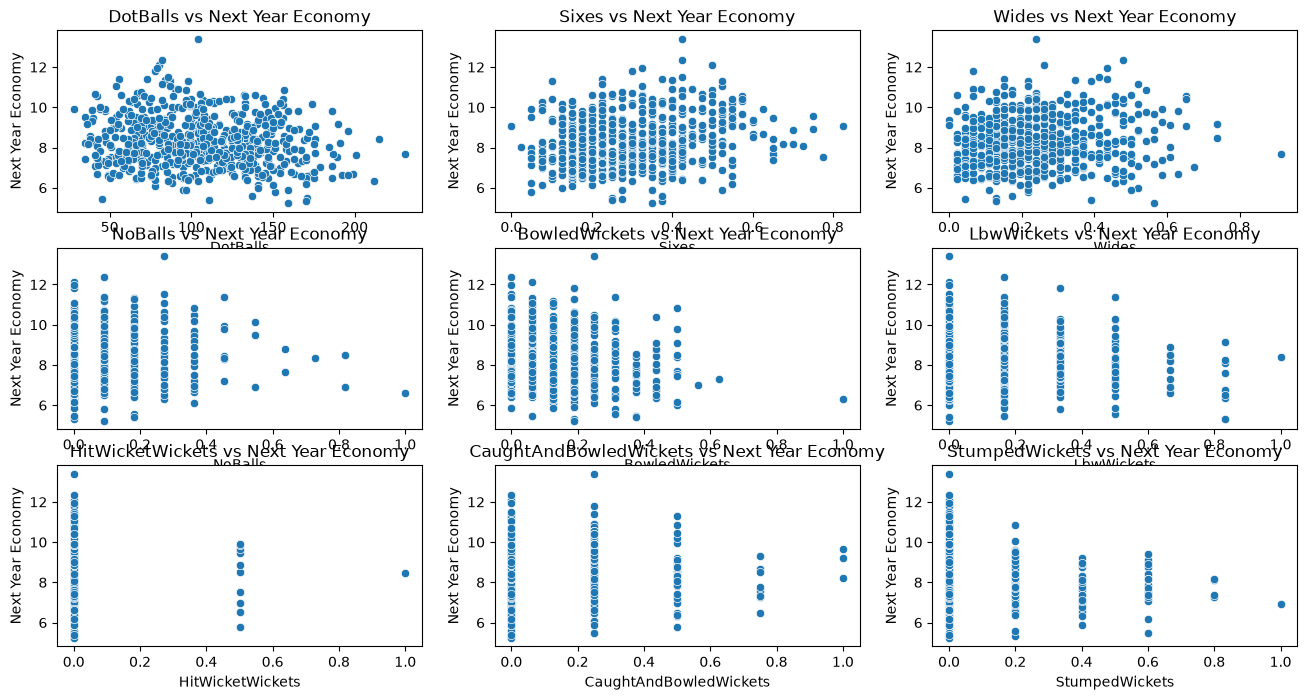

In [275]:
# Plot inputs divided by overs versus next year economy (8 subplots, 2 rows of 4)
plt.figure(figsize=(16, 8))

for i, column in enumerate(['DotBalls', 'Sixes', 'Wides', 'NoBalls', 'BowledWickets', 'LbwWickets', 'HitWicketWickets', 'CaughtAndBowledWickets', 'StumpedWickets']):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(x=column, y='next_year_economy', data=recent_year_bowler_df)
    plt.title(f'{column} vs Next Year Economy')
    plt.xlabel(column)
    plt.ylabel('Next Year Economy')

plt.show()


# Next steps

Do this one at a time!
1. Scale inputs from 0 to 1 (min to max) across all data (For training and FIB calc)
2. Plot vals and look for non-linear terms
3. Look into type of bowler
    - Maybe other info?
